# Ch1 回授控制導論(Introduction to Controls)

**對應原書**:George Ellis, *Control System Design Guide* 4/e, Chapter 1
**軟體替代**:Visual ModelQ 方塊圖 → python-control 傳遞函數 + Matplotlib

## 學習目標
1. 理解開迴路(open-loop)與閉迴路(closed-loop)控制的差異。
2. 觀察回授如何降低系統對**受控體參數變化**的敏感度。
3. 觀察回授如何抑制**外部擾動**。

## 理論重點
- 閉迴路轉移函數:$T(s) = \dfrac{C(s)P(s)}{1 + C(s)P(s)}$
- 迴路增益 $|CP| \gg 1$ 時,$T \approx 1$,輸出幾乎不受 $P$ 變化影響 —— 這就是回授的核心價值。
- 代價:回授需要感測器,且增益過高會造成不穩定(後續章節主題)。

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path('..').resolve()))
import numpy as np
import matplotlib.pyplot as plt
import control as ct
from common.control_helpers import (first_order, second_order, integrator, inertia,
                                    pi, pid, closed_loop, margins, step_metrics, bandwidth_hz)
from common.sim import (DiscretePID, MotorPlant, DCMotorPlant, TwoMassPlant,
                        Backlash, EncoderModel, Delay, saturate, quantize, coulomb)
from common.dsa import chirp_excitation, prbs_excitation, measure_frf, frf_of_system
from common.plots import bode_compare
np.set_printoptions(precision=4, suppress=True)

## 實驗 1:受控體增益變化 ±50%

受控體為一階系統 $P(s) = \dfrac{K}{0.1s+1}$(例如馬達驅動器的電壓→速度)。
標稱 $K=2$,實際可能在 1~3 之間漂移。

- **開迴路**:直接以 $u = r/K_{nominal} = 0.5$ 驅動。
- **閉迴路**:PI 控制器 $C(s) = 2 + 20/s$。

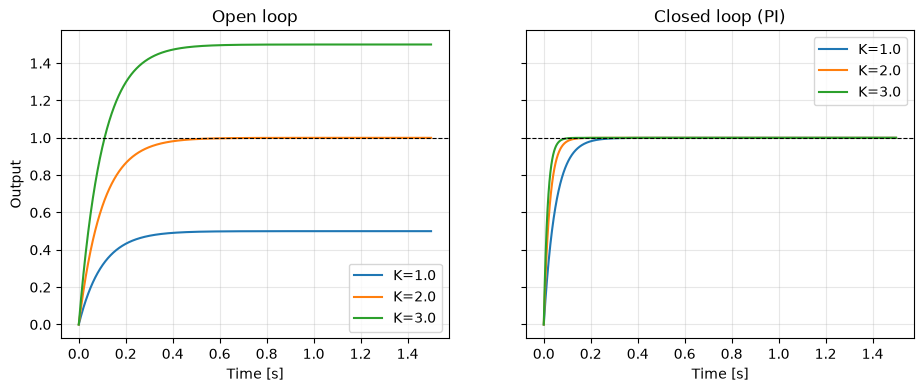

   K      開迴路穩態誤差      閉迴路穩態誤差
 1.0         0.5000       0.000000
 2.0         0.0000      -0.000000
 3.0        -0.5000       0.000000


In [2]:
tau, K_nom = 0.1, 2.0
C = pi(kp=2.0, ki=20.0)
t = np.linspace(0, 1.5, 1500)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
results = {}
for K in [1.0, 2.0, 3.0]:
    P = first_order(tau=tau, gain=K)
    # 開迴路:u = 1/K_nom(以標稱增益反算)
    t_o, y_o = ct.forced_response(P, t, np.ones_like(t) / K_nom)
    # 閉迴路
    T = closed_loop(C, P)
    t_c, y_c = ct.step_response(T, t)
    ax1.plot(t_o, y_o, label=f'K={K}')
    ax2.plot(t_c, y_c, label=f'K={K}')
    results[K] = (float(1 - y_o[-1]), float(1 - y_c[-1]))

for ax, title in [(ax1, 'Open loop'), (ax2, 'Closed loop (PI)')]:
    ax.axhline(1, color='k', ls='--', lw=0.8); ax.grid(alpha=0.3)
    ax.set_xlabel('Time [s]'); ax.legend(); ax.set_title(title)
ax1.set_ylabel('Output')
plt.show()

print(f"{'K':>4} {'開迴路穩態誤差':>12} {'閉迴路穩態誤差':>12}")
for K, (eo, ec) in results.items():
    print(f"{K:>4} {eo:>14.4f} {ec:>14.6f}")

## 實驗 2:擾動抑制

t = 0.75 s 時在受控體輸入端注入 -0.5 的階躍擾動(例如負載突增)。
開迴路完全無法反應;閉迴路的積分器會將誤差收斂回零。

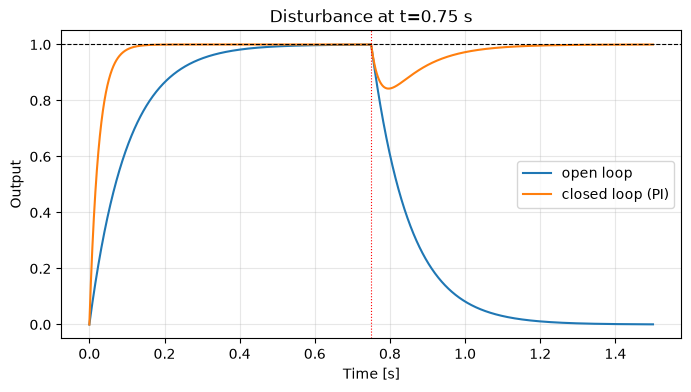

開迴路最終誤差 : 0.9994
閉迴路最終誤差 : 0.000184


In [3]:
P = first_order(tau=tau, gain=K_nom)
d = np.where(t >= 0.75, -0.5, 0.0)

# 開迴路:y = P*(u + d)
_, y_open = ct.forced_response(P, t, np.ones_like(t) / K_nom + d)

# 閉迴路:對命令 r 與擾動 d 分別疊加(線性系統疊加原理)
T_r = closed_loop(C, P)          # r -> y
T_d = ct.feedback(P, C)          # d -> y = P/(1+CP)
_, y_r = ct.step_response(T_r, t)
_, y_d = ct.forced_response(T_d, t, d)
y_closed = y_r + y_d

plt.figure(figsize=(8, 4))
plt.plot(t, y_open, label='open loop')
plt.plot(t, y_closed, label='closed loop (PI)')
plt.axhline(1, color='k', ls='--', lw=0.8)
plt.axvline(0.75, color='r', ls=':', lw=0.8)
plt.xlabel('Time [s]'); plt.ylabel('Output'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Disturbance at t=0.75 s')
plt.show()
print('開迴路最終誤差 :', f'{1 - y_open[-1]:.4f}')
print('閉迴路最終誤差 :', f'{1 - y_closed[-1]:.6f}')

In [4]:
# ✅ 驗證(golden checks)
assert abs(results[2.0][0]) < 1e-3                 # 標稱下開迴路無誤差
assert abs(results[1.0][0] - 0.5) < 0.01           # K=1 時開迴路誤差 50%
for K in [1.0, 2.0, 3.0]:
    assert abs(results[K][1]) < 1e-3, '閉迴路穩態誤差應趨近 0'
assert abs(1 - y_open[-1] - 0.5 * K_nom * 0.5) > 0.2   # 開迴路留下明顯擾動誤差
assert abs(1 - y_closed[-1]) < 1e-3                # 閉迴路把擾動誤差收斂掉
print('Ch1 驗證通過 ✅')

Ch1 驗證通過 ✅


## 練習
1. 把 PI 改成純 P(`pi(kp=2, ki=0)`),閉迴路穩態誤差變成多少?為什麼?
2. 把 `ki` 提高到 200,step response 出現什麼現象?(提示:第 3 章調機)
3. 令受控體時間常數 tau 也漂移 ±50%,閉迴路是否仍然穩健?
4. 計算實驗 1 中閉迴路的靈敏度 $S = 1/(1+CP)$ 在低頻的大小,對照數值結果。